## XAI EEGnet

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix


from captum.attr import (
    Saliency,
    IntegratedGradients,
    Occlusion,
    NoiseTunnel
)

import shap

c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class SpatioTemporalCNN(nn.Module):
    def __init__(
        self,
        in_channels=18,
        window_size=256,
        temporal_filters=16,
        spatial_filters=32,
        num_classes=1,
        temporal_kernel=15,
        dropout_p=0.3,
        spatial_dropout_p=0.1,
        temporal_norm='instance',
    ):
        super().__init__()
        assert temporal_kernel % 2 == 1, 'temporal_kernel debe ser impar para mantener longitud temporal.'

        self.in_channels = in_channels
        self.window_size = window_size
        self.temporal_filters = temporal_filters
        self.spatial_filters = spatial_filters

        self.temporal_conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=in_channels * temporal_filters,
            kernel_size=temporal_kernel,
            padding=(temporal_kernel - 1) // 2,
            groups=in_channels,
            bias=False,
        )
        self.temporal_shortcut = nn.Conv1d(
            in_channels,
            in_channels * temporal_filters,
            kernel_size=1,
            groups=in_channels,
            bias=False,
        )

        if temporal_norm == 'instance':
            self.bn_temp = nn.InstanceNorm1d(in_channels * temporal_filters, affine=True)
        elif temporal_norm == 'batch':
            self.bn_temp = nn.BatchNorm1d(in_channels * temporal_filters)
        else:
            raise ValueError("temporal_norm debe ser 'instance' o 'batch'.")

        self.spatial_conv = nn.Conv1d(
            in_channels=in_channels * temporal_filters,
            out_channels=spatial_filters,
            kernel_size=1,
            bias=False,
        )
        self.spatial_shortcut = nn.Conv1d(
            in_channels * temporal_filters,
            spatial_filters,
            kernel_size=1,
            bias=False,
        )
        self.bn_spat = nn.InstanceNorm1d(spatial_filters, affine=True)

        self.pool = nn.AvgPool1d(kernel_size=8, stride=8)
        self.spatial_dropout = nn.Dropout1d(p=spatial_dropout_p)

        self.conv_refine = nn.Conv1d(
            spatial_filters,
            spatial_filters * 2,
            kernel_size=3,
            padding=1,
            bias=False,
        )
        self.refine_shortcut = nn.Conv1d(
            spatial_filters,
            spatial_filters * 2,
            kernel_size=1,
            bias=False,
        )
        self.bn_refine = nn.InstanceNorm1d(spatial_filters * 2, affine=True)
        self.pool2 = nn.AvgPool1d(kernel_size=4, stride=4)
        self.dropout = nn.Dropout(p=dropout_p)

        self.final_feature_dim = self._infer_feature_dim()
        self.fc = nn.Linear(self.final_feature_dim, num_classes)

    def _forward_features(self, x):
        residual1 = self.temporal_shortcut(x)
        x = self.temporal_conv(x)
        x = self.bn_temp(x)
        x = F.elu(x + residual1)

        residual2 = self.spatial_shortcut(x)
        x = self.spatial_conv(x)
        x = self.bn_spat(x)
        x = F.elu(x + residual2)

        x = self.pool(x)
        x = self.spatial_dropout(x)

        residual3 = self.refine_shortcut(x)
        x = self.conv_refine(x)
        x = self.bn_refine(x)
        x = F.elu(x + residual3)

        x = self.pool2(x)
        x = self.spatial_dropout(x)
        return x

    def _infer_feature_dim(self):
        was_training = self.training
        self.eval()
        with torch.no_grad():
            dummy = torch.zeros(1, self.in_channels, self.window_size)
            x = self._forward_features(dummy)
            feature_dim = x.flatten(1).shape[1]
        self.train(was_training)
        return feature_dim

    def forward(self, x, return_embedding=False, return_logits=True):
        x = self._forward_features(x)
        x = x.flatten(1)
        if return_embedding and not return_logits:
            return x
        x = self.dropout(x)
        logits = self.fc(x)
        if return_embedding:
            return logits, x
        return logits

    def freeze_temporal_block(self, freeze_shortcut=True, freeze_norm=True):
        for p in self.temporal_conv.parameters():
            p.requires_grad = False
        if freeze_shortcut:
            for p in self.temporal_shortcut.parameters():
                p.requires_grad = False
        if freeze_norm:
            for p in self.bn_temp.parameters():
                p.requires_grad = False

    def unfreeze_temporal_block(self):
        for module in [self.temporal_conv, self.temporal_shortcut, self.bn_temp]:
            for p in module.parameters():
                p.requires_grad = True

    def freeze_backbone_except_head(self):
        for module in [
            self.temporal_conv,
            self.temporal_shortcut,
            self.bn_temp,
            self.spatial_conv,
            self.spatial_shortcut,
            self.bn_spat,
            self.conv_refine,
            self.refine_shortcut,
            self.bn_refine,
        ]:
            for p in module.parameters():
                p.requires_grad = False
        for p in self.fc.parameters():
            p.requires_grad = True

    def get_spatial_attention(self, x_after_spatial):
        return torch.softmax(x_after_spatial.mean(dim=-1), dim=1)

In [3]:
class EEGDataset(Dataset):
    def __init__(self, root_dir, sets=None):
        self.root_dir = root_dir

        if sets is None:
            sets = ['set_A','set_B','set_C','set_D','set_E']

        self.samples = []
        self.labels = []
        self.label_map = {s: i for i, s in enumerate(sets)}

        for set_name in sets:
            folder = os.path.join(root_dir, set_name)

            for file in sorted(os.listdir(folder)):
                if file.endswith('.txt'):
                    self.samples.append(os.path.join(folder, file))
                    self.labels.append(self.label_map[set_name])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path = self.samples[idx]

        signal = np.loadtxt(path)

        # convertir a tensor
        signal = torch.tensor(signal, dtype=torch.float32)

        # asegurar formato (canal=1, tiempo)
        signal = signal.unsqueeze(0)

        # normalización
        signal = (signal - signal.mean()) / (signal.std() + 1e-8)

        label = torch.tensor(self.labels[idx], dtype=torch.long)

        return signal, label

In [4]:
class EEGTransforms:
    def __init__(self, noise_std_range=(0.01, 0.05), scale_range=(0.8, 1.2)):
        self.noise_min, self.noise_max = noise_std_range
        self.scale_min, self.scale_max = scale_range

    def __call__(self, signal):
        scale_factor = torch.empty(1).uniform_(self.scale_min, self.scale_max).item()
        signal = signal * scale_factor
        std = torch.empty(1).uniform_(self.noise_min, self.noise_max).item()
        noise = torch.randn_like(signal) * std
        return signal + noise


class SeizureDatasetMultichannel(Dataset):
    def __init__(
        self,
        signals_path,
        labels_path,
        indices=None,
        augment=False,
        sequence_length=1,
        num_samples=1352243
    ):
        self.signals_path = signals_path
        self.labels_path = labels_path
        self.indices = np.asarray(indices) if indices is not None else np.arange(num_samples)

        self.augment = augment
        self.sequence_length = sequence_length
        self.transforms = EEGTransforms() if self.augment else None

        self.num_samples = num_samples
        self.signals = None
        self.labels = None

    def __len__(self):
        return len(self.indices)

    def _lazy_init(self):
        if self.signals is None:
            self.signals = np.memmap(
                self.signals_path,
                dtype='float32',
                mode='r',
                shape=(self.num_samples, 18, 256)
            )
            self.labels = np.memmap(
                self.labels_path,
                dtype='float32',
                mode='r',
                shape=(self.num_samples,)
            )

    def __getitem__(self, idx):
        self._lazy_init()

        real_idx = int(self.indices[idx])

        if self.sequence_length == 1:
            signal = self.signals[real_idx]
            label = self.labels[real_idx]
        else:
            start_idx = max(0, real_idx - self.sequence_length + 1)
            signal_seq = self.signals[start_idx:real_idx + 1]

            pad_len = self.sequence_length - len(signal_seq)
            if pad_len > 0:
                pad = np.repeat(signal_seq[0:1], pad_len, axis=0)
                signal_seq = np.concatenate([pad, signal_seq], axis=0)

            signal = signal_seq
            label = self.labels[real_idx]

        signal = torch.tensor(np.copy(signal), dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.float32)

        if self.sequence_length == 1:
            mean = signal.mean(dim=1, keepdim=True)
            std = signal.std(dim=1, keepdim=True)
        else:
            mean = signal.mean(dim=(0, 2), keepdim=True)
            std = signal.std(dim=(0, 2), keepdim=True)

        signal = (signal - mean) / (std + 1e-6)

        if self.augment and self.transforms:
            signal = self.transforms(signal)

        return signal, label

In [5]:
root_dir = '../data/raw'

dataset = EEGDataset(root_dir)

print("Total muestras:", len(dataset))

Total muestras: 400


In [6]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_ds, test_ds = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SpatioTemporalCNN(in_channels=1, window_size=4097, num_classes=1).to(device)

try:
    checkpoint = torch.load("../models/eegnet_clinical_best_def.pth", map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print("Checkpoint cargado correctamente")
except RuntimeError as e:
    print("No se pudo cargar el checkpoint por incompatibilidad de arquitectura:", e)
    print("Usando modelo inicializado sin pesos preentrenados.")

model.eval()


No se pudo cargar el checkpoint por incompatibilidad de arquitectura: Error(s) in loading state_dict for SpatioTemporalCNN:
	Missing key(s) in state_dict: "temporal_conv.weight", "temporal_shortcut.weight", "bn_temp.weight", "bn_temp.bias", "spatial_conv.weight", "spatial_shortcut.weight", "bn_spat.weight", "bn_spat.bias", "conv_refine.weight", "refine_shortcut.weight", "bn_refine.weight", "bn_refine.bias". 
	Unexpected key(s) in state_dict: "conv1.weight", "depthwise1.weight", "separable_depth.weight", "separable_point.weight". 
	size mismatch for fc.weight: copying a param with shape torch.Size([1, 128]) from checkpoint, the shape in current model is torch.Size([1, 8192]).
Usando modelo inicializado sin pesos preentrenados.


SpatioTemporalCNN(
  (temporal_conv): Conv1d(1, 16, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
  (temporal_shortcut): Conv1d(1, 16, kernel_size=(1,), stride=(1,), bias=False)
  (bn_temp): InstanceNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  (spatial_conv): Conv1d(16, 32, kernel_size=(1,), stride=(1,), bias=False)
  (spatial_shortcut): Conv1d(16, 32, kernel_size=(1,), stride=(1,), bias=False)
  (bn_spat): InstanceNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  (pool): AvgPool1d(kernel_size=(8,), stride=(8,), padding=(0,))
  (spatial_dropout): Dropout1d(p=0.1, inplace=False)
  (conv_refine): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
  (refine_shortcut): Conv1d(32, 64, kernel_size=(1,), stride=(1,), bias=False)
  (bn_refine): InstanceNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
  (pool2): AvgPool1d(kernel_size=(4,), stride=(4,), padding=(0,))
  (dropou

In [8]:
def predict(model, loader):
    preds_all, labels_all = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            out = model(x)
            #preds = torch.argmax(out, dim=1).cpu().numpy()
            probs = torch.sigmoid(out)
            preds = (probs > 0.5).int().cpu().numpy()

            preds_all.extend(preds)
            labels_all.extend(y.numpy())

    return np.array(preds_all), np.array(labels_all)

              precision    recall  f1-score   support

           0       0.28      0.76      0.40        25
           1       0.18      0.11      0.14        18
           3       0.00      0.00      0.00        18
           4       0.00      0.00      0.00        19

    accuracy                           0.26        80
   macro avg       0.11      0.22      0.14        80
weighted avg       0.13      0.26      0.16        80



c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\naidl\miniconda3\envs\tfm_eeg\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

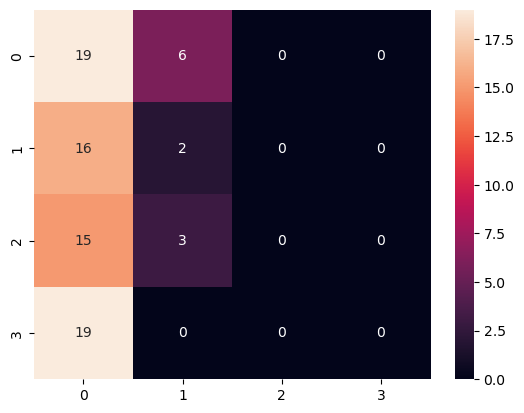

In [9]:
preds, labels = predict(model, test_loader)

print(classification_report(labels, preds))

cm = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

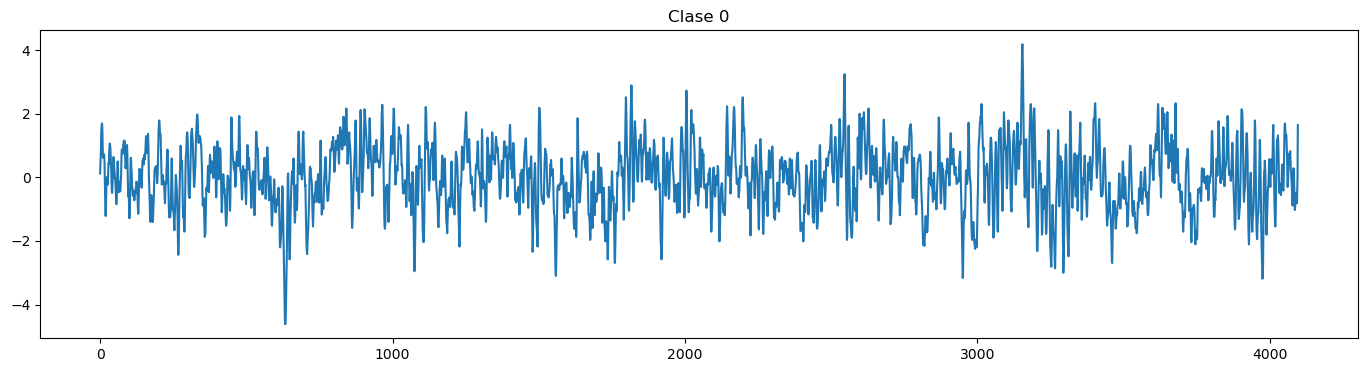

In [10]:
x, y = dataset[0]
x_input = x.unsqueeze(0).to(device)

plt.figure(figsize=(17, 4))
plt.plot(x.squeeze().numpy())
plt.title(f"Clase {y}")
plt.show()

In [11]:
# Obtenemos un lote de datos para las pruebas de XAI
dataiter = iter(test_loader)
signals, labels = next(dataiter)
signals = signals.to(device)

# Seleccionamos una muestra específica (por ejemplo, la primera del lote)
sample_idx = 0
input_signal = signals[sample_idx:sample_idx+1] # Conservar dimensión de batch [1, 1, seq_len]

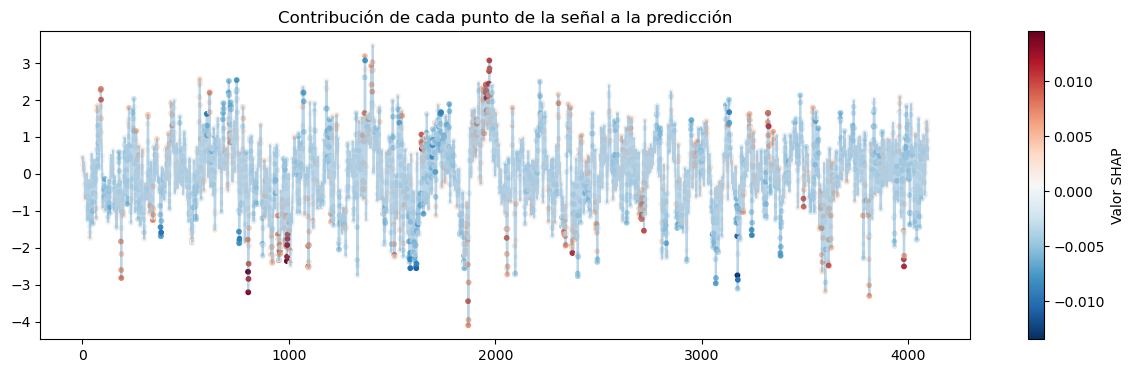

In [12]:
import shap

# 1. Asegúrate de que el modelo esté en modo evaluación
model.eval()

# 2. Preparar datos de fondo (background) y prueba
# Tomamos un lote del loader
batch_signals, _ = next(iter(train_loader))
background = batch_signals[:10].to(device)
test_sample = signals[0:1].to(device)  # Una sola muestra para explicar

# 3. Inicializar GradientExplainer en lugar de DeepExplainer
# GradientExplainer tiene mejor compatibilidad con operaciones PyTorch modernas
explainer = shap.GradientExplainer(model, background)

# 4. Calcular valores SHAP
shap_values = explainer.shap_values(test_sample)

# 5. Visualización (SHAP devuelve una lista para cada salida, tomamos la primera)
shap_val = shap_values[0] if isinstance(shap_values, list) else shap_values
shap_val = np.asarray(shap_val)
if shap_val.ndim > 2:
    shap_val = shap_val.reshape(shap_val.shape[0], -1)
shap_val = shap_val.flatten()

signal_vals = test_sample.cpu().numpy().flatten()
plt.figure(figsize=(15, 4))
plt.plot(signal_vals, label='Señal EEG', alpha=0.3)
plt.scatter(range(len(shap_val)), signal_vals, c=shap_val, cmap='RdBu_r', s=10)
plt.colorbar(label='Valor SHAP')
plt.title("Contribución de cada punto de la señal a la predicción")
plt.show()

C:\Users\naidl\AppData\Local\Temp\ipykernel_41132\4063652799.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  cam = F.relu(torch.tensor(cam)).cpu().detach().numpy()


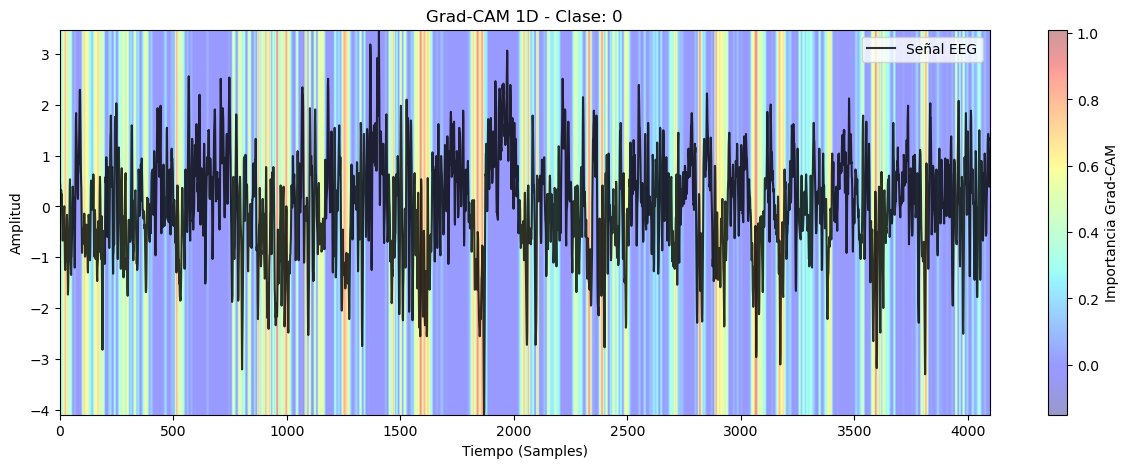

In [15]:
import torch.nn.functional as F

class GradCAM1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Registramos los hooks
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_tensor):
        # Asegurar modo eval pero con gradientes habilitados
        self.model.eval()
        
        # Paso hacia adelante
        output = self.model(input_tensor) # Forma: [1, 1]
        
        # Paso hacia atrás (backward)
        self.model.zero_grad()
        output.backward()

        # 1. Pesos: Promedio de los gradientes por canal (Global Average Pooling de gradientes)
        # self.gradients tiene forma: [Batch*Canales_EEG, Filtros, Longitud_Temporal]
        weights = torch.mean(self.gradients, dim=2, keepdim=True)

        # 2. Mapa de activación: Combinación lineal de activaciones y pesos
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        # 3. ReLU: Nos interesan solo las características que influyen positivamente
        cam = F.relu(torch.tensor(cam)).cpu().detach().numpy()
        
        # 4. Normalización
        if np.max(cam) != np.min(cam):
            cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam))
            
        return cam

# --- EJECUCIÓN ---

# 1. Seleccionamos la capa: Usaremos la última capa convolucional del modelo
# En la clase SpatioTemporalCNN esta capa es conv_refine
target_layer = model.conv_refine

# 2. Instanciamos y generamos
gcam = GradCAM1D(model, target_layer)

# Tomamos una muestra de test (asegúrate de que tenga forma [1, Num_Canales, Tiempo])
sample_signal, sample_label = next(iter(test_loader))
sample_input = sample_signal[0:1].to(device)

mask = gcam.generate(sample_input)

# 3. Visualización
from scipy.ndimage import zoom

plt.figure(figsize=(15, 5))
signal_plot = sample_input.cpu().squeeze().numpy()

# Ajustamos la máscara Grad-CAM al tamaño original de la señal (4097 puntos)
mask_resized = zoom(mask, signal_plot.shape[-1] / len(mask))

# Dibujamos la señal
plt.plot(signal_plot, color='black', alpha=0.8, label='Señal EEG')

# Superponemos el mapa de calor
plt.imshow(mask_resized[np.newaxis, :], aspect='auto', cmap='jet', alpha=0.4, 
           extent=[0, len(signal_plot), np.min(signal_plot), np.max(signal_plot)])

plt.colorbar(label='Importancia Grad-CAM')
plt.title(f'Grad-CAM 1D - Clase: {sample_label[0].item()}')
plt.xlabel('Tiempo (Samples)')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

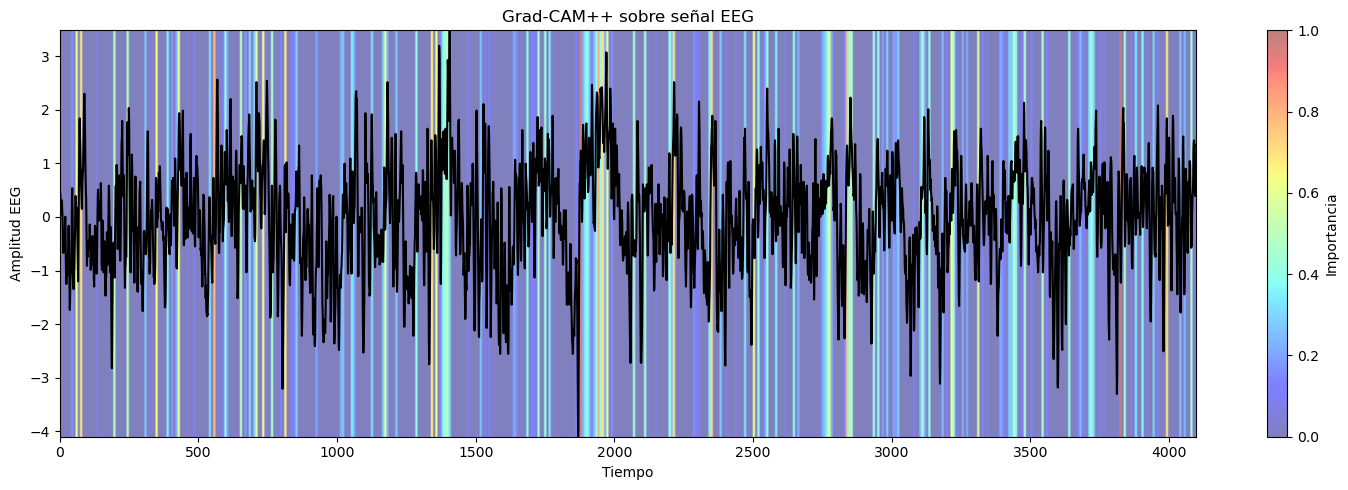

: 

In [ ]:
class GradCAMPlusPlus1D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        # Hooks
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor, class_idx=None):

        self.model.eval()

        # Forward
        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        # Backward
        self.model.zero_grad()

        target = output[:, class_idx]
        target.backward(retain_graph=True)

        activations = self.activations.detach()
        gradients = self.gradients.detach()

        # ======================================
        # Grad-CAM++
        # ======================================

        gradients_power_2 = gradients ** 2
        gradients_power_3 = gradients ** 3

        sum_activations = torch.sum(activations, dim=2, keepdim=True)

        eps = 1e-8

        alpha_denom = (
            2 * gradients_power_2
            + sum_activations * gradients_power_3
        )

        alpha_denom = torch.where(
            alpha_denom != 0.0,
            alpha_denom,
            torch.ones_like(alpha_denom) * eps
        )

        alphas = gradients_power_2 / alpha_denom

        positive_gradients = F.relu(gradients)

        weights = torch.sum(alphas * positive_gradients, dim=2)

        # Corregimos la forma para que tenga la misma dimensión espacial que las activaciones
        weights = weights.unsqueeze(2)

        cam = torch.sum(weights * activations, dim=1)

        # ReLU
        cam = F.relu(cam)

        # Normalización
        cam = cam - cam.min()

        if cam.max() != 0:
            cam = cam / cam.max()

        cam = cam.squeeze().cpu().numpy()

        return cam

# Última capa convolucional

target_layer = model.conv_refine

# Crear objeto Grad-CAM++
gradcam_pp = GradCAMPlusPlus1D(model, target_layer)

# Seleccionar una muestra
sample_signal = signals[0:1].to(device)

# Generar mapa
cam_pp = gradcam_pp.generate_cam(sample_signal)

signal_plot = sample_signal.squeeze().cpu().numpy()

plt.figure(figsize=(15, 5))

# Señal EEG
plt.plot(signal_plot, color='black', linewidth=1.5)

# Heatmap Grad-CAM++
plt.imshow(
    np.expand_dims(cam_pp, axis=0),
    aspect='auto',
    cmap='jet',
    alpha=0.5,
    extent=[0, len(signal_plot), signal_plot.min(), signal_plot.max()]
)

plt.colorbar(label='Importancia')

plt.title('Grad-CAM++ sobre señal EEG')
plt.xlabel('Tiempo')
plt.ylabel('Amplitud EEG')

plt.tight_layout()
plt.show()